In [ ]:
# Install PyTorch Geometric
!pip install torch-geometric -q

# =========================
# IMPORTS
# =========================
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.1 MB/s eta 0:00:00
Using device: cpu


In [ ]:









from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Check what is inside your Drive
print(os.listdir('/content/drive/MyDrive'))

['Trip to gangotri ', 'Saved from Chrome', 'next day wildlifespread', 'Colab Notebooks']


In [ ]:
DATA_PATH = "/content/drive/MyDrive/next day wildlifespread"

print(os.listdir(DATA_PATH)[:5])

['next_day_wildfire_spread_train_00.tfrecord', 'next_day_wildfire_spread_train_01.tfrecord', 'next_day_wildfire_spread_train_02.tfrecord', 'next_day_wildfire_spread_train_03.tfrecord', 'next_day_wildfire_spread_train_04.tfrecord']


In [ ]:
import tensorflow as tf
import numpy as np
import os
import glob

INPUT_DIR = DATA_PATH
OUTPUT_DIR = '/content/processed_data'

# Create folders
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

IMG_SHAPE = [64, 64]

features_dict = {
    'elevation': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'th': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'vs': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'tmmn': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'tmmx': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'sph': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'pr': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'pdsi': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'NDVI': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'erc': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'population': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'PrevFireMask': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'FireMask': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32)
}

def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, features_dict)

    inputs = tf.stack([
        parsed['elevation'], parsed['th'], parsed['vs'],
        parsed['tmmn'], parsed['tmmx'], parsed['sph'],
        parsed['pr'], parsed['pdsi'], parsed['NDVI'],
        parsed['erc'], parsed['population'], parsed['PrevFireMask']
    ], axis=0)

    target = tf.expand_dims(parsed['FireMask'], axis=0)
    return tf.concat([inputs, target], axis=0)

# Load TFRecords
tf_files = sorted(glob.glob(os.path.join(INPUT_DIR, '*.tfrecord')))
print("Total TFRecord files:", len(tf_files))

dataset = tf.data.TFRecordDataset(tf_files)
dataset = dataset.map(parse_tfrecord)

# Convert to list (FULL DATA)
all_data = []
MAX_SAMPLES = None   # Use full dataset

for i, data in enumerate(dataset):
    if MAX_SAMPLES is not None and i >= MAX_SAMPLES:
        break
    all_data.append(data)

print("Loaded samples:", len(all_data))

# Split
total = len(all_data)
train_end = int(0.75 * total)
val_end = int(0.85 * total)

splits = {
    'train': all_data[:train_end],
    'val': all_data[train_end:val_end],
    'test': all_data[val_end:]
}

# Save as numpy
for split, data_list in splits.items():
    print(f"Saving {split} ({len(data_list)} samples)...")
    for i, d in enumerate(data_list):
        np.save(os.path.join(OUTPUT_DIR, split, f'{i}.npy'), d.numpy())

print("\n✅ Data preprocessing done!")

Total TFRecord files: 15
Loaded samples: 14979
Saving train (11234 samples)...
Saving val (1498 samples)...
Saving test (2247 samples)...

✅ Data preprocessing done!


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

class WildfireDataset(Dataset):
    def __init__(self, data_dir, split='train'):
        self.files = sorted([
            os.path.join(data_dir, split, f)
            for f in os.listdir(os.path.join(data_dir, split))
            if f.endswith('.npy')
        ])
        print(f"{split} samples:", len(self.files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])

        x = torch.tensor(data[:-1], dtype=torch.float32)
        y = torch.tensor(data[-1:], dtype=torch.float32)

        # Normalize
        mean = x.mean(dim=(1,2), keepdim=True)
        std = x.std(dim=(1,2), keepdim=True)
        x = (x - mean) / (std + 1e-6)

        return x, y

# Path where processed data saved
DATA_DIR = "/content/processed_data"

# Create datasets
train_dataset = WildfireDataset(DATA_DIR, 'train')
val_dataset = WildfireDataset(DATA_DIR, 'val')
test_dataset = WildfireDataset(DATA_DIR, 'test')

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print("✅ DataLoaders ready!")

train samples: 11234
val samples: 1498
test samples: 2247
✅ DataLoaders ready!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# If torch_geometric not installed, install first
!pip install torch-geometric -q

from torch_geometric.nn import GATConv

# Grid → Graph function
def get_grid_topology(H, W, device):
    src, dst = [], []
    offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    for r in range(H):
        for c in range(W):
            curr = r * W + c
            for dr, dc in offsets:
                nr, nc = r+dr, c+dc
                if 0 <= nr < H and 0 <= nc < W:
                    neigh = nr * W + nc
                    src.append(curr)
                    dst.append(neigh)

    return torch.tensor([src, dst], dtype=torch.long, device=device)


# Model
class HybridFireGNN(nn.Module):
    def __init__(self, in_channels=12, hidden_dim=64):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # GNN
        self.gat1 = GATConv(hidden_dim, hidden_dim)
        self.gat2 = GATConv(hidden_dim, hidden_dim)

        # Decoder
        self.up1 = nn.ConvTranspose2d(hidden_dim, 64, 2, 2)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.up3 = nn.ConvTranspose2d(32, 16, 2, 2)
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        B, C, H, W = x.shape

        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        B, C_lat, H_lat, W_lat = e3.shape

        # Flatten
        x_flat = e3.permute(0,2,3,1).reshape(B*H_lat*W_lat, C_lat)

        # Graph
        edge = get_grid_topology(H_lat, W_lat, x.device)
        edge_batch = torch.cat([edge + i*(H_lat*W_lat) for i in range(B)], dim=1)

        g = F.relu(self.gat1(x_flat, edge_batch))
        g = F.relu(self.gat2(g, edge_batch))

        # Back to grid
        g = g.reshape(B, H_lat, W_lat, C_lat).permute(0,3,1,2)

        # Decoder
        d1 = self.up1(g)
        d2 = self.up2(d1)
        d3 = self.up3(d2)

        out = self.final(d3)
        return out


# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridFireGNN().to(device)

print("✅ Model ready!")

✅ Model ready!


In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn as nn

# Dice Loss
def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


# Loss + Optimizer
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([8.0]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y = (y > 0).float()

        optimizer.zero_grad()
        outputs = model(x)

        loss = bce(outputs, y) + dice_loss(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            y = (y > 0).float()

            outputs = model(x)

            # FIX: use SAME loss here
            loss = bce(outputs, y) + dice_loss(outputs, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

print("✅ Training complete!")

Epoch 1/15 | Train: 1.2474 | Val: 1.1010
Epoch 2/15 | Train: 1.0005 | Val: 1.0147
Epoch 3/15 | Train: 0.9601 | Val: 0.9942
Epoch 4/15 | Train: 0.9356 | Val: 1.0073
Epoch 5/15 | Train: 0.9140 | Val: 0.9830
Epoch 6/15 | Train: 0.8982 | Val: 0.9816
Epoch 7/15 | Train: 0.8772 | Val: 1.0008
Epoch 8/15 | Train: 0.8613 | Val: 0.9669
Epoch 9/15 | Train: 0.8526 | Val: 0.9624
Epoch 10/15 | Train: 0.8376 | Val: 1.0239
Epoch 11/15 | Train: 0.8331 | Val: 0.9723
Epoch 12/15 | Train: 0.8245 | Val: 0.9535
Epoch 13/15 | Train: 0.8154 | Val: 0.9968
Epoch 14/15 | Train: 0.8061 | Val: 0.9719
Epoch 15/15 | Train: 0.7960 | Val: 0.9607
✅ Training complete!


⚠️ No saved model found. Using current model weights.


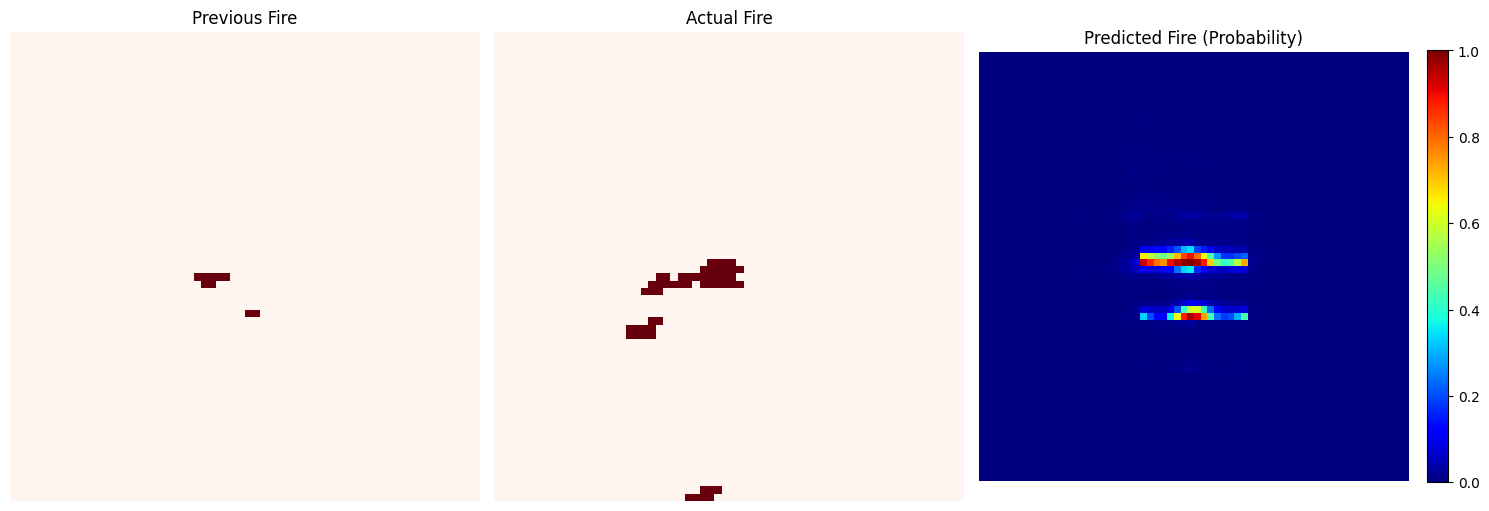

In [ ]:
import torch
import matplotlib.pyplot as plt

# -------- SAFETY: Create model if not exists --------
try:
    model
except NameError:
    print("⚠️ Model not found. Creating new model...")
    model = HybridFireGNN().to(device)

# -------- SAFETY: Load saved weights if available --------
import os
if os.path.exists('best_model.pth'):
    print("✅ Loading saved model weights...")
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
else:
    print("⚠️ No saved model found. Using current model weights.")

model.eval()

# -------- VISUALIZATION FUNCTION --------
def visualize_prediction(model, loader, device):
    model.eval()

    try:
        x, y = next(iter(loader))
    except StopIteration:
        print("❌ Loader is empty!")
        return

    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        logits = model(x)
        pred = torch.sigmoid(logits)

    # Convert safely
    input_fire = x[0, 11].detach().cpu().numpy()
    target_fire = y[0, 0].detach().cpu().numpy()
    predicted_fire = pred[0, 0].detach().cpu().numpy()

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15,5))

    axes[0].imshow(input_fire, cmap='Reds', vmin=0, vmax=1)
    axes[0].set_title("Previous Fire")
    axes[0].axis('off')

    axes[1].imshow(target_fire, cmap='Reds', vmin=0, vmax=1)
    axes[1].set_title("Actual Fire")
    axes[1].axis('off')

    im = axes[2].imshow(predicted_fire, cmap='jet', vmin=0, vmax=1)
    axes[2].set_title("Predicted Fire (Probability)")
    axes[2].axis('off')

    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# -------- RUN --------
visualize_prediction(model, test_loader, device)

In [ ]:
from sklearn.metrics import f1_score, jaccard_score
import numpy as np

def evaluate(model, loader, device):
    model.eval()

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy().flatten())
            all_targets.extend((y > 0).cpu().numpy().flatten())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)

    # Fixed best threshold
    preds = (all_probs > 0.25).astype(float)

    f1 = f1_score(all_targets, preds, zero_division=0)
    iou = jaccard_score(all_targets, preds, zero_division=0)

    print("\n===== FINAL RESULTS =====")
    print(f"Threshold Used: 0.25")
    print(f"Final F1 Score: {f1:.4f}")
    print(f"Final IoU Score: {iou:.4f}")

# Run
evaluate(model, test_loader, device)